# dichasu新数据集015x系列改进网络架构

# Downloading and Reading the CSI Dataset

In [1]:
# Use the following commands to download parts of the dichasus-cf0x dataset.
# This tutorial uses the "old" dataset version (not "rev2") - do not manually download the dataset from the website.
# If you need to manually download the dataset from your browser, please use this website instead:
# https://darus.uni-stuttgart.de/dataset.xhtml?persistentId=doi:10.18419/DARUS-2854&version=2.0
# !mkdir dichasus
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/8 -P dichasus # dichasus-cf02
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/9 -P dichasus # dichasus-cf03
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/10 -P dichasus # dichasus-cf04
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf02.json -P dichasus
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf03.json -P dichasus
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf04.json -P dichasus

In [1]:
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.manifold import trustworthiness
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import distance_matrix
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import multiprocessing as mp
from tqdm.auto import tqdm
import tensorflow as tf
import numpy as np
import random
import queue
import json
        

# Antenna definitions
ASSIGNMENTS = [
    [0, 13, 31, 29, 3, 7, 1, 12 ],
    [30, 26, 21, 25, 24, 8, 22, 15],
    [28, 5, 10, 14, 6, 2, 16, 18],
    [19, 4, 23, 17, 20, 11, 9, 27]
]

ANTENNACOUNT = np.sum([len(antennaArray) for antennaArray in ASSIGNMENTS])

def load_calibrate_timedomain(path, offset_path):
    offsets = None
    with open(offset_path, "r") as offsetfile:
        offsets = json.load(offsetfile)
    
    def record_parse_function(proto):
        record = tf.io.parse_single_example(
            proto,
            {
                "csi": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "pos-tachy": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "time": tf.io.FixedLenFeature([], tf.float32, default_value=0),
            },
        )

        csi = tf.ensure_shape(tf.io.parse_tensor(record["csi"], out_type=tf.float32), (ANTENNACOUNT, 1024, 2))   #CSI向量（32，1024，2）
        csi = tf.complex(csi[:, :, 0], csi[:, :, 1])   #合并为复数 （32，1024）
        csi = tf.signal.fftshift(csi, axes=1)  #FFT移位，0频率移到中心

        position = tf.ensure_shape(tf.io.parse_tensor(record["pos-tachy"], out_type=tf.float64), (3))
        time = tf.ensure_shape(record["time"], ())

        return csi, position[:2], time

    def apply_calibration(csi, pos, time):
        sto_offset = tf.tensordot(tf.constant(offsets["sto"]), 2 * np.pi * tf.range(tf.shape(csi)[1], dtype = np.float32) / tf.cast(tf.shape(csi)[1], np.float32), axes = 0)
        cpo_offset = tf.tensordot(tf.constant(offsets["cpo"]), tf.ones(tf.shape(csi)[1], dtype = np.float32), axes = 0)
        csi = tf.multiply(csi, tf.exp(tf.complex(0.0, sto_offset + cpo_offset)))

        return csi, pos, time

    def csi_time_domain(csi, pos, time):
        csi = tf.signal.fftshift(tf.signal.ifft(tf.signal.fftshift(csi, axes=1)),axes=1)

        return csi, pos, time

    def cut_out_taps(tap_start, tap_stop):
        def cut_out_taps_func(csi, pos, time):
            return csi[:,tap_start:tap_stop], pos, time

        return cut_out_taps_func

    def order_by_antenna_assignments(csi, pos, time):
        csi = tf.stack([tf.gather(csi, antenna_inidces) for antenna_inidces in ASSIGNMENTS])
        return csi, pos, time
    
    dataset = tf.data.TFRecordDataset(path)
    
    dataset = dataset.map(record_parse_function, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(apply_calibration, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(csi_time_domain, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(cut_out_taps(507, 520), num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(order_by_antenna_assignments, num_parallel_calls = tf.data.AUTOTUNE)

    return dataset

inputpaths = [
    {
        "tfrecords" : "dichasus/dichasus-0152.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-015x.json"
    },
    {
        "tfrecords" : "dichasus/dichasus-0153.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-015x.json"
    },
    {
        "tfrecords" : "dichasus/dichasus-0154.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-015x.json"
    }
]

full_dataset = load_calibrate_timedomain(inputpaths[0]["tfrecords"], inputpaths[0]["offsets"])

for path in inputpaths[1:]:
    full_dataset = full_dataset.concatenate(load_calibrate_timedomain(path["tfrecords"], path["offsets"]))

/workspace/anaconda/envs/py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-16 06:39:30.403323: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-16 06:39:30.470831: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-16 06:39:31.783773: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see sl

In [2]:
# Decimate dataset: Use only every 4th datapoint (to reduce number of points)
training_set = full_dataset.shard(4, 0)

# From TensorFlow to NumPy

转换原因：
1.传统机器学习库的需要，大多数scikit-learn算法需要numpy数组输入；科学计算生态系统的兼容
2.numpy针对CPU操作优化，可以一次性加载到内存，对于小到中等数据集内存缓存可以加速迭代
3.tensorflow在调试的时候不方便，需要eval或numpy才能看到值

In [3]:
groundtruth_positions = []
csi_time_domain = []
timestamps = []

for csi, pos, time in training_set.batch(1000):
    csi_time_domain.append(csi.numpy())
    groundtruth_positions.append(pos.numpy())
    timestamps.append(time.numpy())

csi_time_domain = np.concatenate(csi_time_domain)
groundtruth_positions = np.concatenate(groundtruth_positions)
timestamps = np.concatenate(timestamps)

2026-01-16 06:40:04.642773: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-01-16 06:40:12.707872: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
import numpy as np

# --- 1. 更鲁棒的数据重塑 (Robust Reshape for Transformer) ---

X_complex = csi_time_domain
X_real = np.real(X_complex)
X_imag = np.imag(X_complex)

# 堆叠实虚部 -> 此时形状可能是 (N, 32, 13, 2) 或 (N, 4, 8, 13, 2)
X_temp = np.stack([X_real, X_imag], axis=-1)

print(f"原始 X_temp 形状: {X_temp.shape}")

if X_temp.ndim == 5:
    # 情况 A: 形状为 (N, 4, 8, 13, 2)
    # 说明包含天线的高度(4)和宽度(8)
    n_samples, h, w, n_taps, n_channels = X_temp.shape
    n_antennas = h * w # 4 * 8 = 32
    
    # 将 H, W 合并为天线序列 (Sequence Length)，将 Taps, Channels 合并为特征 (Feature Dim)
    X_transformer = X_temp.reshape(n_samples, n_antennas, n_taps * n_channels)

elif X_temp.ndim == 4:
    # 情况 B: 形状为 (N, 32, 13, 2)
    # 说明天线已经是展平的
    n_samples, n_antennas, n_taps, n_channels = X_temp.shape
    
    # 将 Taps, Channels 合并为特征
    X_transformer = X_temp.reshape(n_samples, n_antennas, n_taps * n_channels)

else:
    raise ValueError(f"意料之外的数据维度: {X_temp.shape}, 请检查数据源。")

# --- 标准化 (保持不变) ---
mean = np.mean(X_transformer, axis=(0, 1), keepdims=True)
std = np.std(X_transformer, axis=(0, 1), keepdims=True)
X_norm = (X_transformer - mean) / (std + 1e-8)

print(f"修正后的 Transformer 输入形状: {X_norm.shape}") 
# 预期输出: (N, 32, 26)


原始 X_temp 形状: (10757, 4, 8, 13, 2)
修正后的 Transformer 输入形状: (10757, 32, 26)


In [23]:
X_input.shape

(10757, 4, 8, 26)

In [6]:
# --- 2. Triplet 生成器 (沿用之前的逻辑，确保返回元组) ---
class TransformerTripletGen(tf.keras.utils.Sequence):
    def __init__(self, x_data, timestamps, batch_size=64, margin_pos=1.0, margin_neg=10.0):
        self.x = x_data
        self.t = timestamps
        self.batch_size = batch_size
        self.n_samples = x_data.shape[0]
        # 预计算索引加速
        self.pos_thresh = margin_pos
        self.neg_thresh = margin_neg

    def __len__(self):
        return self.n_samples // self.batch_size

    def __getitem__(self, index):
        indices = np.random.randint(0, self.n_samples, self.batch_size)
        anchors, positives, negatives = [], [], []
        
        for idx in indices:
            t_anchor = self.t[idx]
            
            # 简单挖掘策略 (可优化)
            # 正样本: 1秒内
            # 负样本: 10秒外 (强迫网络学习全局差异)
            
            # 快速随机查找
            pos_idx = idx
            for _ in range(20):
                cand = np.random.randint(0, self.n_samples)
                if np.abs(self.t[cand] - t_anchor) < self.pos_thresh and cand != idx:
                    pos_idx = cand
                    break
            
            neg_idx = idx
            for _ in range(20):
                cand = np.random.randint(0, self.n_samples)
                if np.abs(self.t[cand] - t_anchor) > self.neg_thresh:
                    neg_idx = cand
                    break
            
            anchors.append(self.x[idx])
            positives.append(self.x[pos_idx])
            negatives.append(self.x[neg_idx])
            
        return (np.array(anchors), np.array(positives), np.array(negatives)), np.zeros(self.batch_size)

# 生成器实例
# Batch Size 建议 64 或 128，Transformer 显存占用较大
gen = TransformerTripletGen(X_norm, timestamps, batch_size=64)

In [7]:
def build_csi_transformer(input_shape, embed_dim=64, num_heads=4, ff_dim=128, num_layers=2):
    """
    input_shape: (32, 26) -> (Sequence Length, Feature Dim)
    """
    inputs = layers.Input(shape=input_shape)
    
    # 1. Input Projection (将 26维 特征投影到 embed_dim)
    x = layers.Dense(embed_dim)(inputs)
    
    # 2. Positional Encoding (给每根天线加位置信息)
    # 因为天线是有序排列的，位置信息很重要
    seq_len = input_shape[0]
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)(positions)
    x = x + pos_embedding
    
    # 3. Transformer Encoder Blocks
    for _ in range(num_layers):
        # Self Attention
        # attention_output shape: (Batch, 32, embed_dim)
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
        x1 = layers.Add()([x, attention_output]) # Residual
        x1 = layers.LayerNormalization(epsilon=1e-6)(x1)
        
        # Feed Forward
        ffn = models.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        ffn_output = ffn(x1)
        x = layers.Add()([x1, ffn_output]) # Residual
        x = layers.LayerNormalization(epsilon=1e-6)(x)

    # 4. Global Pooling (聚合所有天线的信息)
    # 可以用 GlobalAveragePooling1D 或 Flatten
    x = layers.GlobalAveragePooling1D()(x)
    
    # 5. Projection Head (降维到 2D Channel Chart)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    
    # 输出层 (2维坐标)
    outputs = layers.Dense(2, activation="linear", name="chart_coords")(x)
    
    return models.Model(inputs, outputs, name="CSI_Transformer")

# 构建模型
# input_shape = (32, 26)
transformer_encoder = build_csi_transformer(input_shape=(32, 26), num_heads=4, num_layers=2)
transformer_encoder.summary()

Model: "CSI_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 26)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32, 64)    │      1,728 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 64)    │     66,368 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 32, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 32, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 32, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 32, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]   

 Total params: 176,706 (690.26 KB)

 Trainable params: 176,706 (690.26 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
class TripletModel(models.Model):
    def __init__(self, encoder, margin=1.0):
        super(TripletModel, self).__init__()
        self.encoder = encoder
        self.margin = margin
        # 追踪 Loss 指标
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def call(self, inputs):
        return self.encoder(inputs)

    def train_step(self, data):
        # Unpack data
        (anchor, positive, negative), _ = data

        with tf.GradientTape() as tape:
            # Forward pass
            anchor_emb = self.encoder(anchor, training=True)
            positive_emb = self.encoder(positive, training=True)
            negative_emb = self.encoder(negative, training=True)

            # Calculate distances
            # D(A, P)
            pos_dist = tf.reduce_sum(tf.square(anchor_emb - positive_emb), axis=1)
            # D(A, N)
            neg_dist = tf.reduce_sum(tf.square(anchor_emb - negative_emb), axis=1)

            # Triplet Loss
            loss = tf.maximum(pos_dist - neg_dist + self.margin, 0.0)
            loss = tf.reduce_mean(loss)

        # Backward pass
        grads = tape.gradient(loss, self.encoder.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.encoder.trainable_weights))

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

# 编译与训练
triplet_transformer = TripletModel(transformer_encoder, margin=1.0)
triplet_transformer.compile(optimizer=optimizers.Adam(learning_rate=0.0005)) # Transformer 学习率可以稍低

print("Training Transformer...")
history = triplet_transformer.fit(gen, epochs=30, steps_per_epoch=100)

Training Transformer...
Epoch 1/30


/workspace/anaconda/envs/py39/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-01-16 06:44:46.258689: I external/local_xla/xla/service/service.cc:163] XLA service 0x73dca4002320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-16 06:44:46.258729: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-01-16 06:44:46.258738: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA L40S, Compute Capability 8.9
2026-01-16 06:44:46.258745: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (2): NVIDIA L40S, Compute Capabil

  6/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.7357

I0000 00:00:1768545905.831254  277630 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 0.2980
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1973
Epoch 3/30
  6/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1026

/workspace/anaconda/envs/py39/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1384
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1227 
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1339
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1500 
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1288
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1395 
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1141
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1132 
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1023
Epoch 12/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1466 
Epoch 13/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1615
Epoch 14/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1604 
Epoch 15/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1634
Epoch 16/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1326 
Epoch 17/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/ste

Predicting with Transformer...


2026-01-16 06:46:26.913066: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-16 06:46:26.913140: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-16 06:46:27.626028: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_412', 104 bytes spill stores, 104 bytes spill loads

2026-01-16 06:46:27.719390: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

34/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

2026-01-16 06:46:29.873957: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-16 06:46:29.874019: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-16 06:46:29.874035: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-16 06:46:29.874055: I external/l

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step
Mean Error after Alignment: 2.2332 m


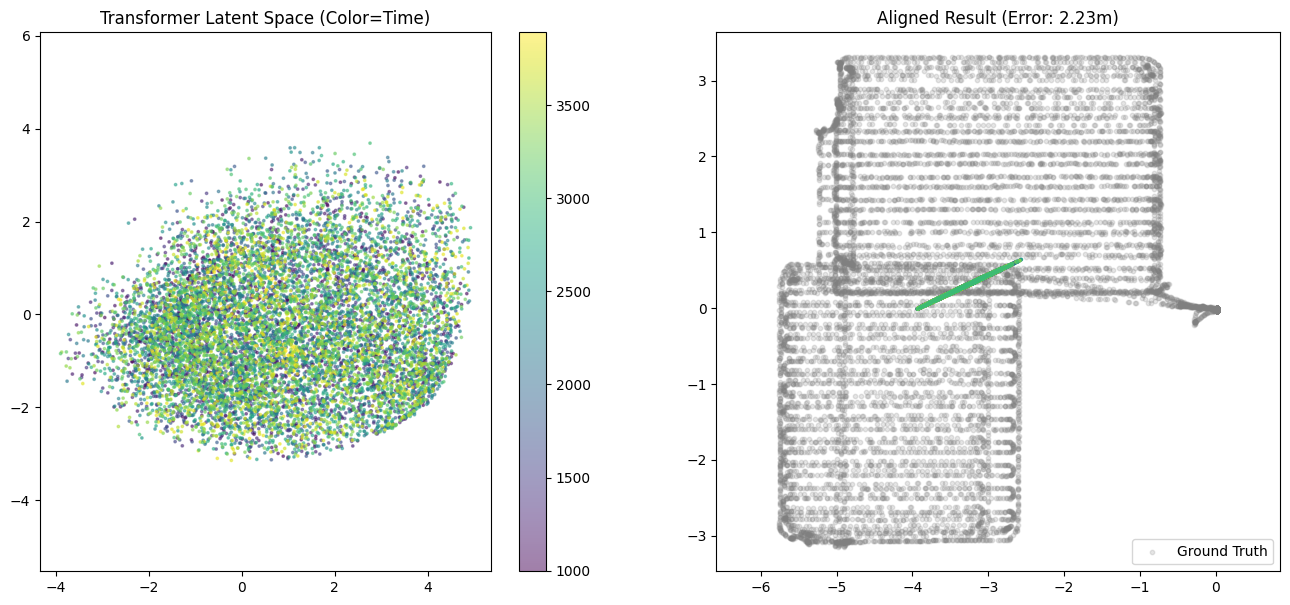

In [9]:
from sklearn.linear_model import LinearRegression

# 1. 预测坐标
print("Predicting with Transformer...")
pred_coords = transformer_encoder.predict(X_norm, batch_size=256)

# 2. 对齐 (Affine Alignment)
# 确保 groundtruth_positions 是 (N, 2)
if 'groundtruth_positions' in locals():
    gt_coords = groundtruth_positions[:, :2]
    
    # 拟合仿射变换
    reg = LinearRegression().fit(pred_coords, gt_coords)
    aligned_coords = reg.predict(pred_coords)
    
    # 计算误差
    err = np.linalg.norm(aligned_coords - gt_coords, axis=1).mean()
    print(f"Mean Error after Alignment: {err:.4f} m")

    # 3. 绘图对比
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # 原始 Latent (用时间着色，看连续性)
    sc1 = axes[0].scatter(pred_coords[:,0], pred_coords[:,1], c=timestamps, s=3, cmap='viridis', alpha=0.5)
    axes[0].set_title("Transformer Latent Space (Color=Time)")
    plt.colorbar(sc1, ax=axes[0])
    axes[0].axis('equal')
    
    # 对齐后 vs 真实轨迹
    axes[1].scatter(gt_coords[:,0], gt_coords[:,1], c='gray', s=10, label='Ground Truth', alpha=0.2)
    sc2 = axes[1].scatter(aligned_coords[:,0], aligned_coords[:,1], c=timestamps, s=3, cmap='viridis', alpha=0.7)
    axes[1].set_title(f"Aligned Result (Error: {err:.2f}m)")
    axes[1].legend()
    axes[1].axis('equal')
    
    plt.show()
else:
    print("No groundtruth positions found for comparison.")

In [8]:
# 确保 groundtruth_positions 可用
# 如果你之前的代码没有保留这个变量，需要重新从 dataset 中提取
if 'groundtruth_positions' not in locals():
    print("Reloading groundtruth positions...")
    groundtruth_positions = []
    # 注意：这里假设 training_set 还是之前的那个 dataset 对象
    # 如果 dataset 被打乱(shuffle)过，必须保证这里的提取顺序和训练数据的顺序完全一致！
    # 最好的方法是在最初预处理时就保存 X_input, timestamps, 和 groundtruth_positions
    for _, pos, _ in training_set.batch(1000):
        groundtruth_positions.append(pos.numpy())
    groundtruth_positions = np.concatenate(groundtruth_positions)
    print(f"Ground truth shape: {groundtruth_positions.shape}")

Predicting channel chart...
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
Mean Positioning Error (after affine alignment): 1.7719 m
Axis Correlations: X=0.48, Y=0.68 (Close to 1.0 is better)


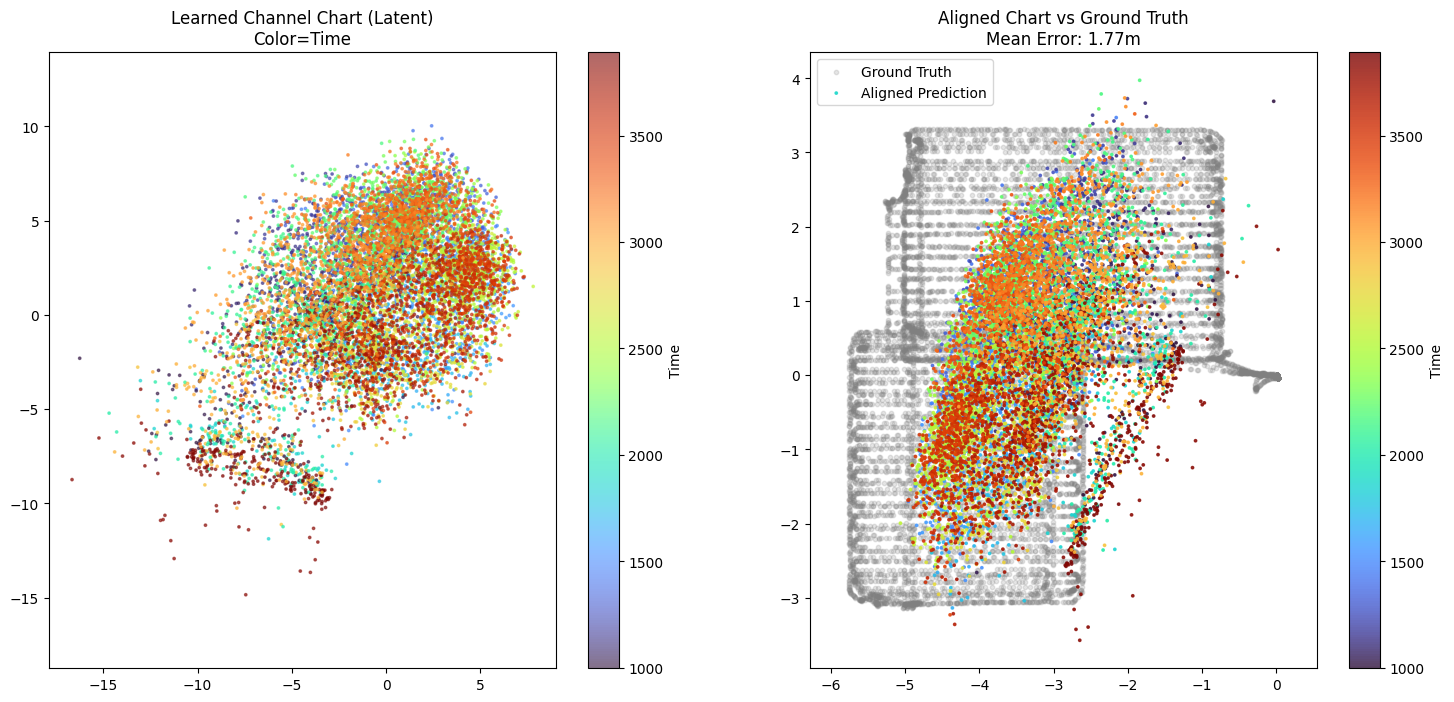

In [10]:
# --- 3. 推断 (Inference) ---
print("Predicting channel chart...")
channel_chart = encoder.predict(X_norm, batch_size=512)

# --- 4. 仿射变换与评估 (Alignment & Evaluation) ---
# 确保 groundtruth_positions 是 (N, 2) 或 (N, 3)
gt_2d = groundtruth_positions[:, :2]

def evaluate_chart(pred_coords, true_coords):
    # 1. 仿射变换 (Learn W, b to map Pred -> True)
    reg = LinearRegression().fit(pred_coords, true_coords)
    aligned_coords = reg.predict(pred_coords)
    
    # 2. 计算误差 (MRE)
    errors = np.linalg.norm(aligned_coords - true_coords, axis=1)
    mean_error = np.mean(errors)
    
    # 3. 计算相关性 (Continuity metric - global structure)
    # 简单计算 x/y 轴的相关系数，看是否有大扭曲
    corr_x = np.corrcoef(aligned_coords[:,0], true_coords[:,0])[0,1]
    corr_y = np.corrcoef(aligned_coords[:,1], true_coords[:,1])[0,1]
    
    return aligned_coords, mean_error, (corr_x, corr_y)

aligned_chart, m_error, corrs = evaluate_chart(channel_chart, gt_2d)
print(f"Mean Positioning Error (after affine alignment): {m_error:.4f} m")
print(f"Axis Correlations: X={corrs[0]:.2f}, Y={corrs[1]:.2f} (Close to 1.0 is better)")

# --- 5. 绘图 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 原始网络输出 (Latent Space)
sc1 = axes[0].scatter(channel_chart[:, 0], channel_chart[:, 1], c=timestamps, cmap='turbo', s=3, alpha=0.6)
axes[0].set_title(f"Learned Channel Chart (Latent)\nColor=Time")
axes[0].axis('equal')
plt.colorbar(sc1, ax=axes[0], label='Time')

# 对齐后的结果 vs 真实轨迹
axes[1].scatter(gt_2d[:, 0], gt_2d[:, 1], c='gray', s=10, label='Ground Truth', alpha=0.2)
sc2 = axes[1].scatter(aligned_chart[:, 0], aligned_chart[:, 1], c=timestamps, cmap='turbo', s=3, label='Aligned Prediction', alpha=0.8)
axes[1].set_title(f"Aligned Chart vs Ground Truth\nMean Error: {m_error:.2f}m")
axes[1].axis('equal')
axes[1].legend()
plt.colorbar(sc2, ax=axes[1], label='Time')

plt.show()